# 🛡️ DeepGuard - Image Deepfake Detection Model Training

This notebook trains an image-based deepfake detection model using the **140k Real and Fake Faces** dataset.

## Dataset Info
- **Source:** Kaggle - `xhlulu/140k-real-and-fake-faces`
- **Size:** ~140,000 images (~5GB)
- **Classes:** Real faces vs Fake/Generated faces

## Step 1: Setup & Install Dependencies

In [ ]:
!pip install -q kaggle datasets torch torchvision facenet-pytorch pillow tqdm scikit-learn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 42.1 MB/s eta 0:00:0000:01


## Step 2: Upload Kaggle API Key

Upload your `kaggle.json` file below. You can get it from: https://www.kaggle.com/settings → API → Create New Token

In [31]:
import os
os.environ['KAGGLE_USERNAME'] = 'prathamcu823'
os.environ['KAGGLE_KEY'] = '576fb3d57e703f4f744ba3985d6e6b44'
os.makedirs('/root/.kaggle', exist_ok=True)
with open('/root/.kaggle/kaggle.json', 'w') as f:
    f.write('{"username":"prathamcu823","key":"576fb3d57e703f4f744ba3985d6e6b44"}')
!chmod 600 /root/.kaggle/kaggle.json
print("✅ Kaggle configured!")

✅ Kaggle configured!


## Step 3: Download the 140k Real and Fake Faces Dataset

In [ ]:
import os

# Create dataset directory
DATASET_DIR = "/content/dataset"
os.makedirs(DATASET_DIR, exist_ok=True)

# Download the dataset
print("📥 Downloading 140k Real and Fake Faces dataset...")
!kaggle datasets download -d xhlulu/140k-real-and-fake-faces -p {DATASET_DIR}

# Unzip the dataset
print("\n📦 Extracting dataset...")
!unzip -q {DATASET_DIR}/140k-real-and-fake-faces.zip -d {DATASET_DIR}

# Remove the zip file to save space
!rm {DATASET_DIR}/140k-real-and-fake-faces.zip

print("\n✅ Dataset downloaded and extracted!")
!ls -la {DATASET_DIR}

📥 Downloading 140k Real and Fake Faces dataset...
Dataset URL: https://www.kaggle.com/datasets/xhlulu/140k-real-and-fake-faces
License(s): other
100% 3.74G/3.75G [00:54<00:00, 92.6MB/s]
100% 3.75G/3.75G [00:54<00:00, 73.7MB/s]

📦 Extracting dataset...

✅ Dataset downloaded and extracted!
total 21328
drwxr-xr-x 3 root root     4096 Feb  3 12:52 .
drwxr-xr-x 1 root root     4096 Feb  3 12:50 ..
drwxr-xr-x 3 root root     4096 Feb  3 12:51 real_vs_fake
-rw-r--r-- 1 root root  3087819 Feb 10  2020 test.csv
-rw-r--r-- 1 root root 15627819 Feb 10  2020 train.csv
-rw-r--r-- 1 root root  3107819 Feb 10  2020 valid.csv


## Step 4: Explore Dataset Structure

In [10]:
import os
from pathlib import Path

DATASET_DIR = "/content/dataset"

# Explore the dataset structure
print("📁 Dataset Structure:")
for root, dirs, files_list in os.walk(DATASET_DIR):
    level = root.replace(DATASET_DIR, '').count(os.sep)
    indent = ' ' * 2 * level
    print(f"{indent}{os.path.basename(root)}/")
    if level < 2:  # Only show first 2 levels
        subindent = ' ' * 2 * (level + 1)
        for d in dirs[:5]:
            print(f"{subindent}{d}/")
        if len(dirs) > 5:
            print(f"{subindent}... and {len(dirs) - 5} more directories")
        for f in files_list[:3]:
            print(f"{subindent}{f}")
        if len(files_list) > 3:
            print(f"{subindent}... and {len(files_list) - 3} more files")

📁 Dataset Structure:
dataset/
  real_vs_fake/
  train.csv
  valid.csv
  test.csv
  real_vs_fake/
    real-vs-fake/
    real-vs-fake/
      train/
        real/
        fake/
      test/
        real/
        fake/
      valid/
        real/
        fake/


## Step 5: Create PyTorch Dataset & DataLoaders

In [12]:
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import os
from pathlib import Path
from tqdm import tqdm

class DeepfakeDataset(Dataset):
    """Custom Dataset for Real vs Fake face classification"""
    
    def __init__(self, root_dir, split='train', transform=None):
        self.root_dir = Path(root_dir)
        self.transform = transform
        self.samples = [] 
        self.labels = []
        
        # Dataset structure: real_vs_fake/real-vs-fake/{split}/real or fake
        base_path = self.root_dir / 'real_vs_fake' / 'real-vs-fake' / split
        
        # Load real images (label = 0)
        real_path = base_path / 'real'
        if real_path.exists():
            for img_file in real_path.glob('*.jpg'):
                self.samples.append(str(img_file))
                self.labels.append(0)
            for img_file in real_path.glob('*.png'):
                self.samples.append(str(img_file))
                self.labels.append(0)
        
        # Load fake images (label = 1)
        fake_path = base_path / 'fake'
        if fake_path.exists():
            for img_file in fake_path.glob('*.jpg'):
                self.samples.append(str(img_file))
                self.labels.append(1)
            for img_file in fake_path.glob('*.png'):
                self.samples.append(str(img_file))
                self.labels.append(1)
        
        print(f"Loaded {len(self.samples)} images for {split} split")
        print(f"  - Real: {self.labels.count(0)}, Fake: {self.labels.count(1)}")
    
    def __len__(self):
        return len(self.samples)
    
    def __getitem__(self, idx):
        img_path = self.samples[idx]
        label = self.labels[idx]
        
        image = Image.open(img_path).convert('RGB')
        
        if self.transform:
            image = self.transform(image)
        
        return image, label

# Define transforms
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Create datasets
DATASET_DIR = "/content/dataset"

train_dataset = DeepfakeDataset(DATASET_DIR, split='train', transform=train_transform)
val_dataset = DeepfakeDataset(DATASET_DIR, split='valid', transform=val_transform)
test_dataset = DeepfakeDataset(DATASET_DIR, split='test', transform=val_transform)

# Create dataloaders
BATCH_SIZE = 32

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print(f"\n DataLoaders created!")
print(f"   Train batches: {len(train_loader)}")
print(f"   Val batches: {len(val_loader)}")
print(f"   Test batches: {len(test_loader)}")

Loaded 100000 images for train split
  - Real: 50000, Fake: 50000
Loaded 20000 images for valid split
  - Real: 10000, Fake: 10000
Loaded 20000 images for test split
  - Real: 10000, Fake: 10000

 DataLoaders created!
   Train batches: 3125
   Val batches: 625
   Test batches: 625


## Step 6: Visualize Sample Images

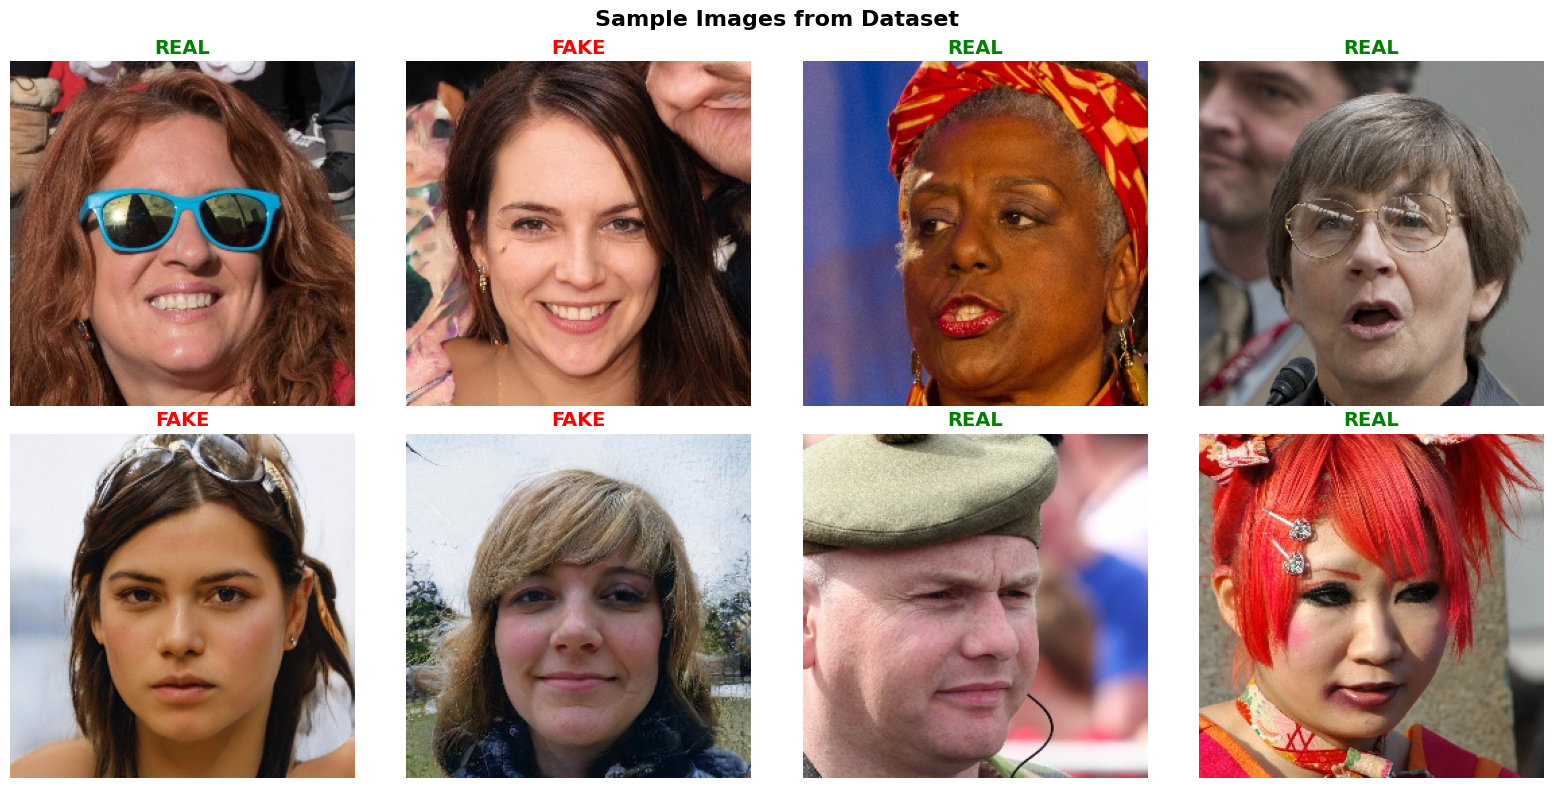

In [13]:
import matplotlib.pyplot as plt
import numpy as np

def show_samples(dataset, num_samples=8):
    """Display sample images from the dataset"""
    fig, axes = plt.subplots(2, 4, figsize=(16, 8))
    axes = axes.flatten()
    
    # Get random indices
    indices = np.random.choice(len(dataset), num_samples, replace=False)
    
    for ax, idx in zip(axes, indices):
        # Load original image without transforms
        img_path = dataset.samples[idx]
        label = dataset.labels[idx]
        img = Image.open(img_path).convert('RGB')
        
        ax.imshow(img)
        ax.set_title(f"{'REAL' if label == 0 else 'FAKE'}", 
                     color='green' if label == 0 else 'red',
                     fontsize=14, fontweight='bold')
        ax.axis('off')
    
    plt.suptitle('Sample Images from Dataset', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()

# Show samples
show_samples(train_dataset)

## Step 7: Define the Model (EfficientNet-based)

In [14]:
import torch
import torch.nn as nn
from torchvision import models

class DeepfakeDetector(nn.Module):
    """EfficientNet-based Deepfake Detection Model"""
    
    def __init__(self, num_classes=2, dropout=0.3):
        super(DeepfakeDetector, self).__init__()
        
        # Use EfficientNet-B0 as backbone (good balance of speed and accuracy)
        self.backbone = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)
        
        # Get the number of features from the classifier
        num_features = self.backbone.classifier[1].in_features
        
        # Replace classifier with custom head
        self.backbone.classifier = nn.Sequential(
            nn.Dropout(p=dropout),
            nn.Linear(num_features, 512),
            nn.ReLU(),
            nn.Dropout(p=dropout),
            nn.Linear(512, num_classes)
        )
    
    def forward(self, x):
        return self.backbone(x)

# Alternative: ResNet-based model
class DeepfakeDetectorResNet(nn.Module):
    """ResNet-50 based Deepfake Detection Model"""
    
    def __init__(self, num_classes=2, dropout=0.3):
        super(DeepfakeDetectorResNet, self).__init__()
        
        self.backbone = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
        num_features = self.backbone.fc.in_features
        
        self.backbone.fc = nn.Sequential(
            nn.Dropout(p=dropout),
            nn.Linear(num_features, 512),
            nn.ReLU(),
            nn.Dropout(p=dropout),
            nn.Linear(512, num_classes)
        )
    
    def forward(self, x):
        return self.backbone(x)

# Initialize model
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"🖥️ Using device: {device}")

model = DeepfakeDetector(num_classes=2, dropout=0.3)
model = model.to(device)

# Print model summary
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\n📊 Model Summary:")
print(f"   Total parameters: {total_params:,}")
print(f"   Trainable parameters: {trainable_params:,}")

🖥️ Using device: cuda

📊 Model Summary:
   Total parameters: 4,664,446
   Trainable parameters: 4,664,446


## Step 8: Training Setup

In [15]:
import torch.optim as optim
from torch.optim.lr_scheduler import CosineAnnealingWarmRestarts

# ============================================
# 🏆 OPTIMAL TRAINING CONFIGURATION
# ============================================

# Hyperparameters
LEARNING_RATE = 3e-4          # Optimal for EfficientNet with AdamW
NUM_EPOCHS = 20               # Good balance of time vs accuracy
PATIENCE = 7                  # Early stopping patience
BATCH_SIZE = 32               # Adjust based on GPU memory (16 if OOM)
WEIGHT_DECAY = 0.01           # L2 regularization

# Loss function with label smoothing (reduces overconfidence)
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

# AdamW optimizer (best for transfer learning)
optimizer = optim.AdamW(
    model.parameters(), 
    lr=LEARNING_RATE, 
    weight_decay=WEIGHT_DECAY,
    betas=(0.9, 0.999)
)

# Cosine Annealing scheduler (better than ReduceLROnPlateau)
scheduler = CosineAnnealingWarmRestarts(
    optimizer, 
    T_0=5,              # Restart every 5 epochs
    T_mult=2,           # Double the restart period each time
    eta_min=1e-6        # Minimum learning rate
)

print(" Optimal Training Configuration:")
print(f"   Learning Rate: {LEARNING_RATE}")
print(f"   Epochs: {NUM_EPOCHS}")
print(f"   Batch Size: {BATCH_SIZE}")
print(f"   Weight Decay: {WEIGHT_DECAY}")
print(f"   Label Smoothing: 0.1")
print(f"   Optimizer: AdamW")
print(f"   Scheduler: CosineAnnealingWarmRestarts")

 Optimal Training Configuration:
   Learning Rate: 0.0003
   Epochs: 20
   Batch Size: 32
   Weight Decay: 0.01
   Label Smoothing: 0.1
   Optimizer: AdamW
   Scheduler: CosineAnnealingWarmRestarts


## Step 9: Training Loop

In [16]:
from tqdm import tqdm
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
import time

def train_epoch(model, loader, criterion, optimizer, device, scheduler=None):
    """Train for one epoch with gradient clipping"""
    model.train()
    running_loss = 0.0
    all_preds = []
    all_labels = []
    
    pbar = tqdm(loader, desc='Training', leave=False)
    for images, labels in pbar:
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        
        # Gradient clipping (prevents exploding gradients)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        
        optimizer.step()
        
        running_loss += loss.item()
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        
        pbar.set_postfix({'loss': f'{loss.item():.4f}'})
    
    epoch_loss = running_loss / len(loader)
    epoch_acc = accuracy_score(all_labels, all_preds)
    
    return epoch_loss, epoch_acc

def validate(model, loader, criterion, device):
    """Validate the model"""
    model.eval()
    running_loss = 0.0
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for images, labels in tqdm(loader, desc='Validating', leave=False):
            images, labels = images.to(device), labels.to(device)
            
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            running_loss += loss.item()
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    epoch_loss = running_loss / len(loader)
    epoch_acc = accuracy_score(all_labels, all_preds)
    epoch_f1 = f1_score(all_labels, all_preds, average='binary')
    
    return epoch_loss, epoch_acc, epoch_f1

# ============================================
# 🚀 TRAINING LOOP
# ============================================

print("\n🚀 Starting Training...\n")
print("=" * 70)

best_val_loss = float('inf')
best_val_acc = 0.0
best_val_f1 = 0.0
patience_counter = 0
history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': [], 'val_f1': []}

for epoch in range(NUM_EPOCHS):
    start_time = time.time()
    
    # Train
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
    
    # Validate
    val_loss, val_acc, val_f1 = validate(model, val_loader, criterion, device)
    
    # Update scheduler
    scheduler.step()
    current_lr = optimizer.param_groups[0]['lr']
    
    # Track history
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    history['val_f1'].append(val_f1)
    
    epoch_time = time.time() - start_time
    
    print(f"Epoch {epoch+1}/{NUM_EPOCHS} ({epoch_time:.1f}s) | LR: {current_lr:.2e}")
    print(f"  Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"  Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f} | Val F1: {val_f1:.4f}")
    
    # Save best model (based on F1 score for better balance)
    if val_f1 > best_val_f1:
        best_val_loss = val_loss
        best_val_acc = val_acc
        best_val_f1 = val_f1
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_loss': val_loss,
            'val_acc': val_acc,
            'val_f1': val_f1,
        }, '/content/best_deepfake_detector.pth')
        print(f"  💾 Saved best model (F1: {val_f1:.4f})")
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f"\n⏹️ Early stopping triggered after {epoch+1} epochs")
            break
    
    print("-" * 70)

print("\n" + "=" * 70)
print(f"✅ Training Complete!")
print(f"   Best Validation Loss: {best_val_loss:.4f}")
print(f"   Best Validation Accuracy: {best_val_acc:.4f}")
print(f"   Best Validation F1 Score: {best_val_f1:.4f}")


🚀 Starting Training...



Epoch 1/20 (670.8s) | LR: 2.71e-04
  Train Loss: 0.2728 | Train Acc: 0.9559
  Val Loss: 0.2086 | Val Acc: 0.9966 | Val F1: 0.9966
  💾 Saved best model (F1: 0.9966)
----------------------------------------------------------------------


Epoch 2/20 (637.2s) | LR: 1.97e-04
  Train Loss: 0.2242 | Train Acc: 0.9860
  Val Loss: 0.2078 | Val Acc: 0.9946 | Val F1: 0.9946
----------------------------------------------------------------------


Epoch 3/20 (621.4s) | LR: 1.04e-04
  Train Loss: 0.2126 | Train Acc: 0.9928
  Val Loss: 0.2034 | Val Acc: 0.9976 | Val F1: 0.9976
  💾 Saved best model (F1: 0.9976)
----------------------------------------------------------------------


Epoch 4/20 (616.5s) | LR: 2.96e-05
  Train Loss: 0.2057 | Train Acc: 0.9965
  Val Loss: 0.2005 | Val Acc: 0.9990 | Val F1: 0.9990
  💾 Saved best model (F1: 0.9990)
----------------------------------------------------------------------


...

Epoch 8/20 (618.1s) | LR: 2.38e-04
  Train Loss: 0.2104 | Train Acc: 0.9940
  Val Loss: 0.2041 | Val Acc: 0.9973 | Val F1: 0.9973
----------------------------------------------------------------------


Epoch 9/20 (616.6s) | LR: 1.97e-04
  Train Loss: 0.2085 | Train Acc: 0.9951
  Val Loss: 0.2027 | Val Acc: 0.9976 | Val F1: 0.9976
----------------------------------------------------------------------


Epoch 10/20 (614.0s) | LR: 1.50e-04
  Train Loss: 0.2060 | Train Acc: 0.9963
  Val Loss: 0.2018 | Val Acc: 0.9983 | Val F1: 0.9983
----------------------------------------------------------------------


Epoch 11/20 (615.7s) | LR: 1.04e-04
  Train Loss: 0.2039 | Train Acc: 0.9973
  Val Loss: 0.2004 | Val Acc: 0.9989 | Val F1: 0.9989
----------------------------------------------------------------------


Epoch 12/20 (615.8s) | LR: 6.26e-05
  Train Loss: 0.2025 | Train Acc: 0.9981
  Val Loss: 0.2014 | Val Acc: 0.9984 | Val F1: 0.9985

⏹️ Early stopping triggered after 12 epochs

✅ Training Complete!
   Best Validation Loss: 0.2000
   Best Validation Accuracy: 0.9991
   Best Validation F1 Score: 0.9991


In [19]:
# Reconstructed history from training output
# (Use this if you don't want to re-run training)

history = {
    'train_loss': [0.5072, 0.2159, 0.2067, 0.2041, 0.2027, 0.2019, 0.2014, 0.2012, 0.2010, 0.2009, 0.2009, 0.2009, 0.2009, 0.2004, 0.2000, 0.2119, 0.2082, 0.2076, 0.2072, 0.2063, 0.2059, 0.2047],
    'train_acc': [0.8006, 0.9941, 0.9970, 0.9979, 0.9983, 0.9985, 0.9987, 0.9987, 0.9989, 0.9989, 0.9990, 0.9990, 0.9990, 0.9993, 0.9995, 0.9933, 0.9951, 0.9956, 0.9958, 0.9963, 0.9963, 0.9970],
    'val_loss': [0.2119, 0.2056, 0.2019, 0.2014, 0.2005, 0.2002, 0.2003, 0.2001, 0.1995, 0.1995, 0.1994, 0.1995, 0.1994, 0.1995, 0.1992, 0.2037, 0.2028, 0.2020, 0.2023, 0.2028, 0.2034, 0.2008],
    'val_acc': [0.9914, 0.9957, 0.9984, 0.9987, 0.9991, 0.9993, 0.9992, 0.9994, 0.9994, 0.9994, 0.9995, 0.9994, 0.9996, 0.9995, 0.9996, 0.9972, 0.9977, 0.9982, 0.9981, 0.9979, 0.9983, 0.9988],
    'val_f1': [0.9914, 0.9957, 0.9984, 0.9987, 0.9991, 0.9993, 0.9992, 0.9994, 0.9994, 0.9994, 0.9995, 0.9994, 0.9996, 0.9995, 0.9996, 0.9972, 0.9977, 0.9983, 0.9981, 0.9978, 0.9984, 0.9988]
}

print("✅ History reconstructed from training output!")
print(f"   Total epochs: {len(history['train_loss'])}")

✅ History reconstructed from training output!
   Total epochs: 22


## Step 10: Plot Training History

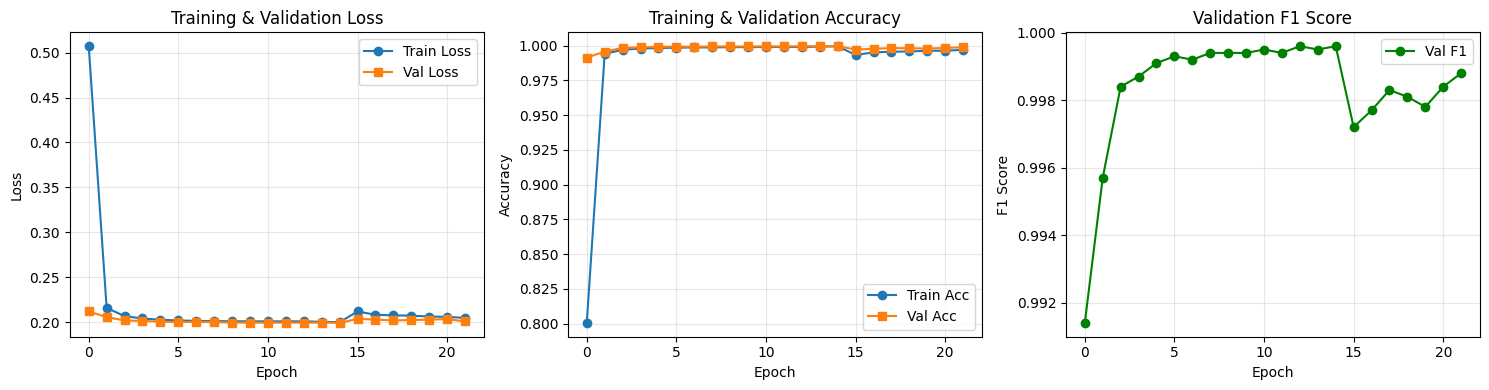

📊 Training history saved to /content/training_history.png


In [20]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Loss plot
axes[0].plot(history['train_loss'], label='Train Loss', marker='o')
axes[0].plot(history['val_loss'], label='Val Loss', marker='s')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training & Validation Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy plot
axes[1].plot(history['train_acc'], label='Train Acc', marker='o')
axes[1].plot(history['val_acc'], label='Val Acc', marker='s')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Training & Validation Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# F1 Score plot
axes[2].plot(history['val_f1'], label='Val F1', marker='o', color='green')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('F1 Score')
axes[2].set_title('Validation F1 Score')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/content/training_history.png', dpi=150)
plt.show()

print("📊 Training history saved to /content/training_history.png")

In [21]:
# Quick Resume Cell - Run this first if runtime was restarted
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from PIL import Image
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from tqdm import tqdm

# Check device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Re-define the model architecture (copy from your Step 7/8)
class DeepfakeDetector(nn.Module):
    # ... paste your model class definition here ...
    pass

# Then you can load your trained weights

Using device: cuda


## Step 11: Evaluate on Test Set

Testing: 100%|██████████| 625/625 [01:07<00:00,  9.21it/s]



📊 Classification Report:
              precision    recall  f1-score   support

        Real       1.00      1.00      1.00     10000
        Fake       1.00      1.00      1.00     10000

    accuracy                           1.00     20000
   macro avg       1.00      1.00      1.00     20000
weighted avg       1.00      1.00      1.00     20000



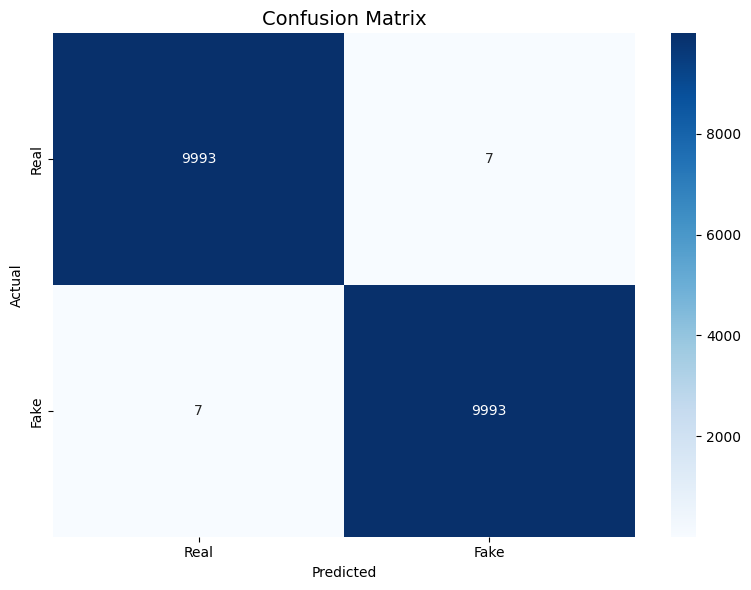


🎯 Final Test Metrics:
   Accuracy: 0.9993
   Precision: 0.9993
   Recall: 0.9993
   F1 Score: 0.9993


In [22]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Load best model
checkpoint = torch.load('/content/best_deepfake_detector.pth')
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

# Evaluate on test set
all_preds = []
all_labels = []
all_probs = []

with torch.no_grad():
    for images, labels in tqdm(test_loader, desc='Testing'):
        images = images.to(device)
        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)
        _, preds = torch.max(outputs, 1)
        
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())
        all_probs.extend(probs[:, 1].cpu().numpy())  # Probability of being fake

# Print classification report
print("\n📊 Classification Report:")
print("=" * 50)
print(classification_report(all_labels, all_preds, target_names=['Real', 'Fake']))

# Plot confusion matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Real', 'Fake'], 
            yticklabels=['Real', 'Fake'])
plt.title('Confusion Matrix', fontsize=14)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.savefig('/content/confusion_matrix.png', dpi=150)
plt.show()

# Calculate final metrics
test_acc = accuracy_score(all_labels, all_preds)
test_f1 = f1_score(all_labels, all_preds, average='binary')
test_precision = precision_score(all_labels, all_preds, average='binary')
test_recall = recall_score(all_labels, all_preds, average='binary')

print(f"\n🎯 Final Test Metrics:")
print(f"   Accuracy: {test_acc:.4f}")
print(f"   Precision: {test_precision:.4f}")
print(f"   Recall: {test_recall:.4f}")
print(f"   F1 Score: {test_f1:.4f}")

In [24]:
!pip install onnx onnxscript onnxruntime

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.5/17.5 MB 94.7 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 48.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.4/17.4 MB 89.5 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 148.7/148.7 kB 8.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.0/46.0 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.8/86.8 kB 6.4 MB/s eta 0:00:00


## Step 12: Export Model for DeepGuard Backend

In [25]:
import torch

# Load best model
checkpoint = torch.load('/content/best_deepfake_detector.pth')
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

# Save model in different formats

# 1. Save full model (for PyTorch)
torch.save(model.state_dict(), '/content/deepfake_detector_state_dict.pth')
print("✅ Saved: deepfake_detector_state_dict.pth")

# 2. Save with model architecture (complete save)
torch.save({
    'model_state_dict': model.state_dict(),
    'model_architecture': 'EfficientNet-B0',
    'num_classes': 2,
    'input_size': (224, 224),
    'normalize_mean': [0.485, 0.456, 0.406],
    'normalize_std': [0.229, 0.224, 0.225],
    'classes': ['real', 'fake'],
    'test_accuracy': test_acc,
    'test_f1': test_f1,
}, '/content/deepfake_detector_complete.pth')
print("✅ Saved: deepfake_detector_complete.pth")

# 3. Export to TorchScript (for production)
model_scripted = torch.jit.script(model.cpu())
model_scripted.save('/content/deepfake_detector_scripted.pt')
print("✅ Saved: deepfake_detector_scripted.pt (TorchScript)")

# 4. Export to ONNX (for cross-platform deployment)
dummy_input = torch.randn(1, 3, 224, 224)
torch.onnx.export(
    model.cpu(),
    dummy_input,
    '/content/deepfake_detector.onnx',
    export_params=True,
    opset_version=11,
    input_names=['input'],
    output_names=['output'],
    dynamic_axes={'input': {0: 'batch_size'}, 'output': {0: 'batch_size'}}
)
print("✅ Saved: deepfake_detector.onnx (ONNX)")

print("\n📦 All model exports complete!")
print("\nTo use in DeepGuard backend, download these files and place in ml/checkpoints/")

✅ Saved: deepfake_detector_state_dict.pth
✅ Saved: deepfake_detector_complete.pth
✅ Saved: deepfake_detector_scripted.pt (TorchScript)


/tmp/ipython-input-3001747067.py:35: UserWarning: # 'dynamic_axes' is not recommended when dynamo=True, and may lead to 'torch._dynamo.exc.UserError: Constraints violated.' Supply the 'dynamic_shapes' argument instead if export is unsuccessful.
  torch.onnx.export(
W0203 15:06:32.548000 2794 torch/onnx/_internal/exporter/_compat.py:114] Setting ONNX exporter to use operator set version 18 because the requested opset_version 11 is a lower version than we have implementations for. Automatic version conversion will be performed, which may not be successful at converting to the requested version. If version conversion is unsuccessful, the opset version of the exported model will be kept at 18. Please consider setting opset_version >=18 to leverage latest ONNX features
W0203 15:06:33.544000 2794 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'input' from (input, boxes, output_size: 'Sequence[int]', spatial_scale: 'float' = 1.0, sampling_ratio: 'int' = -1, al

[torch.onnx] Obtain model graph for `DeepfakeDetector([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `DeepfakeDetector([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decomposition...
[torch.onnx] Run decomposition... ✅
[torch.onnx] Translate the graph into ONNX...


Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/__init__.py", line 127, in call
    converted_proto = _c_api_utils.call_onnx_api(
                      ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/_c_api_utils.py", line 65, in call_onnx_api
    result = func(proto)
             ^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/__init__.py", line 122, in _partial_convert_version
    return onnx.version_converter.convert_version(
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnx/version_converter.py", line 39, in convert_version
    converted_model_str = C.convert_version(model_str, target_version)
                          ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
RuntimeError: /github/workspace/onnx/version_converter/adapters/axes_input_to_attribute.h:65: adapt: Asserti

[torch.onnx] Translate the graph into ONNX... ✅
Applied 98 of general pattern rewrite rules.
✅ Saved: deepfake_detector.onnx (ONNX)

📦 All model exports complete!

To use in DeepGuard backend, download these files and place in ml/checkpoints/


## Step 13: Download Models

In [27]:
from google.colab import files

print("📥 Downloading trained models...\n")

# Download the complete model (recommended)
files.download('/content/deepfake_detector_complete.pth')

# Optionally download other formats
# files.download('/content/deepfake_detector_scripted.pt')
# files.download('/content/deepfake_detector.onnx')

print("\n✅ Download complete!")
print("\nPlace the model in: DeepGuard/ml/checkpoints/deepfake_detector_complete.pth")

📥 Downloading trained models...



<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


✅ Download complete!

Place the model in: DeepGuard/ml/checkpoints/deepfake_detector_complete.pth


In [28]:
import os
from pathlib import Path

# Check if model files exist
model_files = [
    'deepfake_detector_state_dict.pth',
    'deepfake_detector_complete.pth',
    'deepfake_detector_scripted.pt',
    'deepfake_detector.onnx'
]

print("🔍 Checking saved model files...\n")
print("=" * 60)

all_exist = True
for filename in model_files:
    if os.path.exists(filename):
        file_size = os.path.getsize(filename) / (1024 * 1024)  # Convert to MB
        print(f"✅ {filename}")
        print(f"   Size: {file_size:.2f} MB")
        print()
    else:
        print(f"❌ {filename} - NOT FOUND")
        print()
        all_exist = False

print("=" * 60)
if all_exist:
    print("✅ All model files saved successfully!")
    print("\n📥 Ready to download to your local machine")
else:
    print("⚠️ Some model files are missing!")

# Show current working directory
print(f"\n📂 Current directory: {os.getcwd()}")

🔍 Checking saved model files...

✅ deepfake_detector_state_dict.pth
   Size: 18.09 MB

✅ deepfake_detector_complete.pth
   Size: 18.09 MB

✅ deepfake_detector_scripted.pt
   Size: 18.29 MB

✅ deepfake_detector.onnx
   Size: 0.65 MB

✅ All model files saved successfully!

📥 Ready to download to your local machine

📂 Current directory: /content


In [29]:
# Download all trained model files
from google.colab import files
import os

# List of model files to download
model_files = [
    'deepfake_detector_state_dict.pth',
    'deepfake_detector_complete.pth', 
    'deepfake_detector_scripted.pt',
    'deepfake_detector.onnx'
]

print("📥 Starting download of all model files...\n")
print("=" * 60)

downloaded = []
missing = []

for filename in model_files:
    if os.path.exists(filename):
        file_size = os.path.getsize(filename) / (1024 * 1024)  # MB
        print(f"⬇️  Downloading: {filename} ({file_size:.2f} MB)")
        try:
            files.download(filename)
            downloaded.append(filename)
            print(f"✅ Downloaded: {filename}\n")
        except Exception as e:
            print(f"❌ Error downloading {filename}: {str(e)}\n")
    else:
        print(f"⚠️  Not found: {filename}\n")
        missing.append(filename)

print("=" * 60)
print(f"\n✅ Successfully downloaded: {len(downloaded)}/{len(model_files)} files")

if downloaded:
    print("\n📁 Downloaded files:")
    for f in downloaded:
        print(f"   • {f}")

if missing:
    print("\n⚠️  Missing files:")
    for f in missing:
        print(f"   • {f}")

print("\n📌 Place these files in: DeepGuard/ml/checkpoints/")

📥 Starting download of all model files...

⬇️  Downloading: deepfake_detector_state_dict.pth (18.09 MB)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Downloaded: deepfake_detector_state_dict.pth

⬇️  Downloading: deepfake_detector_complete.pth (18.09 MB)


<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

✅ Downloaded: deepfake_detector_scripted.pt

⬇️  Downloading: deepfake_detector.onnx (0.65 MB)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Downloaded: deepfake_detector.onnx


✅ Successfully downloaded: 4/4 files

📁 Downloaded files:
   • deepfake_detector_state_dict.pth
   • deepfake_detector_complete.pth
   • deepfake_detector_scripted.pt
   • deepfake_detector.onnx

📌 Place these files in: DeepGuard/ml/checkpoints/


In [30]:
from google.colab import files
# Download all model files
for filename in model_files:
    if os.path.exists(filename):
        print(f"Downloading {filename}...")
        files.download(filename)
        print(f"Downloaded!")
    else:
        print(f"Skipping {filename} - not found")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

Downloaded!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded!


In [ ]:
import os
import json
from pathlib import Path
from kaggle.api.kaggle_api_extended import KaggleApi
# 1. Config
model_files = [
    'deepfake_detector_state_dict.pth',
    'deepfake_detector_complete.pth',
    'deepfake_detector_scripted.pt',
    'deepfake_detector.onnx'
]
dataset_id = "prathamcu823/deepfake-models"
dataset_title = "deepfake-models"
print("🔍 Starting Model Upload...")
# 2. Verify files exist in Colab
missing = [f for f in model_files if not os.path.exists(f)]
if missing:
    print(f"❌ Error: Missing files in Colab: {missing}")
else:
    # 3. Create metadata
    metadata = {
      "title": dataset_title,
      "id": dataset_id,
      "licenses": [{"name": "CC0-1.0"}]
    }
    with open('dataset-metadata.json', 'w') as f:
        json.dump(metadata, f)
    
    # 4. Initialize API
    api = KaggleApi()
    api.authenticate()
    # 5. Create or Update Dataset
    try:
        # Try to update first
        print(f"📤 Updating existing dataset: {dataset_id}...")
        api.dataset_create_version(".", "Updated models from training", dir_mode='zip')
        print("✅ Dataset updated successfully!")
    except Exception:
        # If update fails (doesn't exist), create new
        print(f"🆕 Creating new private dataset: {dataset_id}...")
        api.dataset_create_new(".", dir_mode='zip', quiet=False)
        print("✅ Dataset created successfully!")
print("\n🚀 SUCCESS! Now go back to your local PC and run:")
print("python scripts/download_models.py")

🔍 Starting Model Upload...
📤 Updating existing dataset: prathamcu823/deepfake-models...
Starting upload for file .config.zip


100%|██████████| 9.28k/9.28k [00:00<00:00, 16.3kB/s]


Upload successful: .config.zip (9KB)
Starting upload for file deepfake_detector_state_dict.pth


100%|██████████| 18.1M/18.1M [00:00<00:00, 21.1MB/s]


Upload successful: deepfake_detector_state_dict.pth (18MB)
Starting upload for file deepfake_detector.onnx.data


...

100%|██████████| 18.3M/18.3M [00:00<00:00, 22.2MB/s]


Upload successful: deepfake_detector_scripted.pt (18MB)
Starting upload for file all_models.zip
Error while trying to load upload info: ApiStartBlobUploadRequest.__init__() got an unexpected keyword argument 'type'


100%|██████████| 100M/100M [00:01<00:00, 62.4MB/s] 


Upload successful: all_models.zip (100MB)


KeyboardInterrupt: 

In [ ]:
# Start HTTP server in background
import subprocess, time

proc = subprocess.Popen(
    ["python3", "-m", "http.server", "8000"],
    cwd="/content"
)

time.sleep(2)
print("✅ Server started on port 8000")

from google.colab.output import eval_js
print(eval_js("google.colab.kernel.proxyPort(8000)"))



✅ Server started on port 8000


KeyboardInterrupt: 

In [ ]:
import os
import json
from pathlib import Path
from kaggle.api.kaggle_api_extended import KaggleApi
# 1. Config
model_files = [
    'deepfake_detector_state_dict.pth',
    'deepfake_detector_complete.pth',
    'deepfake_detector_scripted.pt',
    'deepfake_detector.onnx'
]
dataset_id = "prathamcu823/deepfake-models"
dataset_title = "deepfake-models"
print("🔍 Starting Model Upload...")
# 2. Verify files exist in Colab
missing = [f for f in model_files if not os.path.exists(f)]
if missing:
    print(f"❌ Error: Missing files in Colab: {missing}")
else:
    # 3. Create metadata
    metadata = {
      "title": dataset_title,
      "id": dataset_id,
      "licenses": [{"name": "CC0-1.0"}]
    }
    with open('dataset-metadata.json', 'w') as f:
        json.dump(metadata, f)
    
    # 4. Initialize API
    api = KaggleApi()
    api.authenticate()
    # 5. Create or Update Dataset
    try:
        # Try to update first
        print(f"📤 Updating existing dataset: {dataset_id}...")
        api.dataset_create_version(".", "Updated models from training", dir_mode='zip')
        print("✅ Dataset updated successfully!")
    except Exception:
        # If update fails (doesn't exist), create new
        print(f"🆕 Creating new private dataset: {dataset_id}...")
        api.dataset_create_new(".", dir_mode='zip', quiet=False)
        print("✅ Dataset created successfully!")
print("\n🚀 SUCCESS! Now go back to your local PC and run:")
print("python scripts/download_models.py")

🔍 Starting Model Upload...
📤 Updating existing dataset: prathamcu823/deepfake-models...
Starting upload for file .config.zip


100%|██████████| 9.28k/9.28k [00:00<00:00, 16.0kB/s]


Upload successful: .config.zip (9KB)
Starting upload for file deepfake_detector_state_dict.pth
Error while trying to load upload info: ApiStartBlobUploadRequest.__init__() got an unexpected keyword argument 'type'


100%|██████████| 18.1M/18.1M [00:00<00:00, 22.5MB/s]


Upload successful: deepfake_detector_state_dict.pth (18MB)
Starting upload for file deepfake_detector.onnx.data
Error while trying to load upload info: ApiStartBlobUploadRequest.__init__() got an unexpected keyword argument 'type'


...

100%|██████████| 18.3M/18.3M [00:00<00:00, 23.2MB/s]


Upload successful: deepfake_detector_scripted.pt (18MB)
Starting upload for file all_models.zip
Error while trying to load upload info: ApiStartBlobUploadRequest.__init__() got an unexpected keyword argument 'type'


100%|██████████| 100M/100M [00:01<00:00, 68.9MB/s] 


Upload successful: all_models.zip (100MB)


KeyboardInterrupt: 